# Linear Regression Practical Notebook


We will do two practical parts:

1. **Simple Linear Regression** using one feature: `Hours Studied` → `Exam Score`
2. **Multiple Linear Regression** using a larger dataset with numeric features, categorical features, missing values, and inconsistent text values.

Libraries used: `pandas`, `numpy`, `matplotlib`, and `sklearn`.

## Part 1 — Simple Linear Regression

Dataset:

| Hours Studied | Exam Score |
|---:|---:|
| 1 | 42 |
| 2 | 55 |
| 3 | 53 |
| 4 | 65 |
| 5 | 62 |
| 6 | 75 |
| 7 | 74 |
| 8 | 85 |
| 9 | 82 |
| 10 | 95 |

Goal: Train a model like:

`Exam Score = w × Hours Studied + b`

Here:

- `w` is the **weight / slope / coefficient**
- `b` is the **bias / intercept**

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Create the dataset using pandas DataFrame
data = {
    "hours_studied": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "exam_score": [42, 55, 53, 65, 62, 75, 74, 85, 82, 95]
}

df = pd.DataFrame(data)
df

,hours_studied,exam_score
0,1,42
1,2,55
2,3,53
3,4,65
4,5,62
5,6,75
6,7,74
7,8,85
8,9,82
9,10,95


In [3]:
# Separate input feature X and output target y

# X must be 2D for sklearn, so we use double square brackets [[ ]]
X = df[["hours_studied"]]

# y can be 1D
y = df["exam_score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10, 1)
y shape: (10,)


In [4]:
from sklearn.linear_model import LinearRegression

# Create and train the Linear Regression model using all data
model = LinearRegression()
model.fit(X, y)

print("Model trained successfully!")

Model trained successfully!


In [5]:
# Get w and b values
w = model.coef_[0]
b = model.intercept_

print("w / weight / coefficient:", w)
print("b / bias / intercept:", b)

print(f"Model equation: exam_score = {w:.2f} * hours_studied + {b:.2f}")

w / weight / coefficient: 5.248484848484847
b / bias / intercept: 39.93333333333334
Model equation: exam_score = 5.25 * hours_studied + 39.93


In [7]:
Score = model.score(X, y)
print("R² Score / Accuracy-like score:", round(Score*100, 3))

R² Score / Accuracy-like score: 94.393


In [13]:
# Make a prediction
# Example: Predict exam score for a student who studied 7.5 hours

new_hours = pd.DataFrame({"hours_studied": [7.5]})
predicted_score = model.predict(new_hours)

print(f"Predicted exam score for 7.5 hours studied: {predicted_score[0]:.2f}")

Predicted exam score for 7.5 hours studied: 79.30


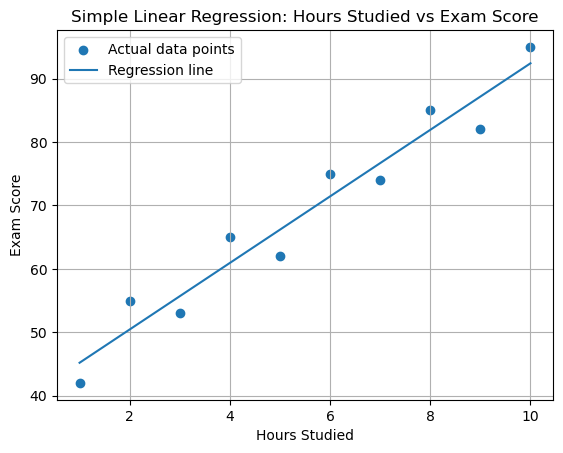

In [14]:
# Plot data points and regression line

# Actual data points
plt.scatter(df["hours_studied"], df["exam_score"], label="Actual data points")

# Regression line
x_line = np.linspace(df["hours_studied"].min(), df["hours_studied"].max(), 100)
y_line = model.predict(pd.DataFrame({"hours_studied": x_line}))
plt.plot(x_line, y_line, label="Regression line")

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Simple Linear Regression: Hours Studied vs Exam Score")
plt.legend()
plt.grid(True)
plt.show()

## Part 2 — Multiple Linear Regression with Data Cleaning

Now we use a larger dataset with more than one feature.

Features:

- `hours_studied` — numeric
- `attendance_percent` — numeric
- `previous_score` — numeric
- `course_type` — categorical
- `difficulty_level` — categorical

Target value:

- `exam_score`

This dataset includes some realistic problems:

- Missing values
- Categorical text data
- Inconsistent category names such as `ML`, `ml`, and `Machine Learning`
- Inconsistent capitalization such as `medium` and `Medium`

In [15]:
# Load the dirty dataset
# Make sure student_performance_dirty.csv is in the same folder as this notebook

df2 = pd.read_csv("student_performance_dirty.csv")
df2.head()

,hours_studied,attendance_percent,previous_score,course_type,difficulty_level,exam_score
0,1.0,60.0,45.0,AI Basics,Medium,42
1,2.0,70.0,50.0,Python,Easy,55
2,3.0,65.0,52.0,AI Basics,Medium,53
3,4.0,75.0,58.0,Python,Medium,65
4,5.0,72.0,60.0,ML,Hard,62


In [16]:
# Basic inspection
print("Dataset shape:", df2.shape)

print("-"*100)
print("Column information:")
print(df2.info())

print("-"*100)
print("Missing values:")
print(df2.isnull().sum())

Dataset shape: (40, 6)
----------------------------------------------------------------------------------------------------
Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   hours_studied       39 non-null     float64
 1   attendance_percent  39 non-null     float64
 2   previous_score      39 non-null     float64
 3   course_type         39 non-null     object 
 4   difficulty_level    39 non-null     object 
 5   exam_score          40 non-null     int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 2.0+ KB
None
----------------------------------------------------------------------------------------------------
Missing values:
hours_studied         1
attendance_percent    1
previous_score        1
course_type           1
difficulty_level      1
exam_score            0
dtype: int64


In [17]:
# Check unique values in categorical columns before cleaning
print("course_type unique values:")
print(df2["course_type"].unique())

print("\ndifficulty_level unique values:")
print(df2["difficulty_level"].unique())

course_type unique values:
['AI Basics' 'Python' 'ML' 'Data Science' nan 'python' 'Machine Learning'
 'AI' 'ml' 'Data science']

difficulty_level unique values:
['Medium' 'Easy' 'Hard' nan 'medium' 'easy']


In [18]:
# Clean inconsistent categorical values

# 1. Standardize text: remove extra spaces and convert to lowercase
df2["course_type"] = df2["course_type"].astype("string").str.strip().str.lower()
df2["difficulty_level"] = df2["difficulty_level"].astype("string").str.strip().str.lower()

# 2. Replace inconsistent course names with standard names
course_mapping = {
    "ml": "machine learning",
    "machine learning": "machine learning",
    "ai": "ai basics",
    "ai basics": "ai basics",
    "python": "python",
    "data science": "data science"
}

df2["course_type"] = df2["course_type"].replace(course_mapping)

# 3. Replace inconsistent difficulty names with standard names
difficulty_mapping = {
    "easy": "easy",
    "medium": "medium",
    "hard": "hard"
}

df2["difficulty_level"] = df2["difficulty_level"].replace(difficulty_mapping)

print("\nCleaned course_type values:")
print(df2["course_type"].unique())

print("\nCleaned difficulty_level values:")
print(df2["difficulty_level"].unique())


Cleaned course_type values:
<StringArray>
['ai basics', 'python', 'machine learning', 'data science', <NA>]
Length: 5, dtype: string

Cleaned difficulty_level values:
<StringArray>
['medium', 'easy', 'hard', <NA>]
Length: 4, dtype: string


In [19]:
# Handle missing values

# Numeric columns: fill missing values with the median
numeric_cols = ["hours_studied", "attendance_percent", "previous_score"]
for col in numeric_cols:
    df2[col] = df2[col].fillna(df2[col].median())

# Categorical columns: fill missing values with the mode
categorical_cols = ["course_type", "difficulty_level"]
for col in categorical_cols:
    df2[col] = df2[col].fillna(df2[col].mode()[0])

print("Missing values after cleaning:")
print(df2.isnull().sum())

Missing values after cleaning:
hours_studied         0
attendance_percent    0
previous_score        0
course_type           0
difficulty_level      0
exam_score            0
dtype: int64


In [20]:
# Convert categorical columns into numerical format using one-hot encoding

df2_encoded = pd.get_dummies(df2, columns=["course_type", "difficulty_level"], drop_first=True)
df2_encoded.head()

,hours_studied,attendance_percent,previous_score,exam_score,course_type_data science,course_type_machine learning,course_type_python,difficulty_level_hard,difficulty_level_medium
0,1.0,60.0,45.0,42,False,False,False,False,True
1,2.0,70.0,50.0,55,False,False,True,False,False
2,3.0,65.0,52.0,53,False,False,False,False,True
3,4.0,75.0,58.0,65,False,False,True,False,True
4,5.0,72.0,60.0,62,False,True,False,True,False


In [21]:
# Separate features X and target y
X = df2_encoded.drop("exam_score", axis=1)
y = df2_encoded["exam_score"]

X.head()

,hours_studied,attendance_percent,previous_score,course_type_data science,course_type_machine learning,course_type_python,difficulty_level_hard,difficulty_level_medium
0,1.0,60.0,45.0,False,False,False,False,True
1,2.0,70.0,50.0,False,False,True,False,False
2,3.0,65.0,52.0,False,False,False,False,True
3,4.0,75.0,58.0,False,False,True,False,True
4,5.0,72.0,60.0,False,True,False,True,False


In [22]:
# Normalize numeric features
# Important: For a real project, fit scaler only on training data.
# For teaching simplicity, we will first split, then fit scaler only on X_train.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

# Only scale numeric columns. One-hot encoded columns should stay as 0/1.
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled.head()

,hours_studied,attendance_percent,previous_score,course_type_data science,course_type_machine learning,course_type_python,difficulty_level_hard,difficulty_level_medium
39,-1.779577,-2.051455,-1.699958,False,False,False,False,False
6,0.576828,0.379899,0.386126,False,False,True,False,False
25,0.969562,1.089044,1.108232,False,False,True,False,False
9,1.755031,1.696882,1.830339,False,True,False,False,True
13,-0.012273,-0.025327,-0.095278,False,True,False,True,False


In [23]:
# Train Multiple Linear Regression model
multi_model = LinearRegression()
multi_model.fit(X_train_scaled, y_train)

print("Multiple Linear Regression model trained successfully!")

Multiple Linear Regression model trained successfully!


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluate the model
y_pred = multi_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))

Mean Absolute Error (MAE): 1.13
Mean Squared Error (MSE): 2.01
Root Mean Squared Error (RMSE): 1.42


### Important note about “accuracy” in Linear Regression

For classification models, we usually use **accuracy**.

For regression models, we usually do **not** use normal accuracy because the model predicts continuous numbers. Instead, we commonly use:

- **MAE**: Average prediction error
- **RMSE**: Error value that gives more weight to large mistakes

For teaching, you can say the **R² score is an accuracy-like score**, but technically it is not classification accuracy.

In [25]:
# Show actual vs predicted values
results = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": y_pred.round(2)
})

results

,Actual Score,Predicted Score
0,54,53.94
1,89,89.56
2,83,80.06
3,90,88.98
4,62,62.75
5,66,65.17
6,56,55.15
7,97,94.98


In [26]:
# Show model coefficients
coefficients = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": multi_model.coef_
}).sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
1,attendance_percent,9.674135
2,previous_score,2.177095
4,course_type_machine learning,2.138905
0,hours_studied,2.032174
5,course_type_python,1.880262
3,course_type_data science,1.619301
7,difficulty_level_medium,0.619066
6,difficulty_level_hard,-0.936392


In [27]:
# Make a new prediction using the trained model

new_student = pd.DataFrame({
    "hours_studied": [7],
    "attendance_percent": [85],
    "previous_score": [75],
    "course_type": ["machine learning"],
    "difficulty_level": ["medium"]
})

# Apply the same one-hot encoding structure as training data
new_student_encoded = pd.get_dummies(new_student, columns=["course_type", "difficulty_level"], drop_first=True)

# Add missing columns that existed during training but are not present in this single input row
new_student_encoded = new_student_encoded.reindex(columns=X.columns, fill_value=0)

# Scale numeric columns using the already trained scaler
new_student_encoded[numeric_cols] = scaler.transform(new_student_encoded[numeric_cols])

new_prediction = multi_model.predict(new_student_encoded)

print(f"Predicted exam score for the new student: {new_prediction[0]:.2f}")

Predicted exam score for the new student: 78.51
